In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [ ]:
df = pd.read_csv("superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
df['Sales'].sum()

np.float64(2297200.8603000003)

In [ ]:
df['Profit'].sum()

np.float64(286397.0217)

In [ ]:
df['Order ID'].nunique()

5009

In [ ]:
import sqlite3

conn = sqlite3.connect('superstore.db')

In [ ]:
df.to_sql('superstore', conn, if_exists='replace', index=False)

9994

SQL Section

Top 10 Products by Sales

In [ ]:
query = """
SELECT "Product Name",
       SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10
"""

pd.read_sql_query(query, conn)

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


Top States by Profit

In [ ]:
query2 = """
SELECT
    State,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM superstore
GROUP BY State
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query2, conn)

,State,Total_Profit
0,California,76381.39
1,New York,74038.55
2,Washington,33402.65
3,Michigan,24463.19
4,Virginia,18597.95
5,Indiana,18382.94
6,Georgia,16250.04
7,Kentucky,11199.70
8,Minnesota,10823.19
9,Delaware,9977.37


Category-wise Sales

In [ ]:
query3 = """
SELECT
    Category,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM superstore
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

pd.read_sql_query(query3, conn)

,Category,Total_Sales
0,Technology,836154.03
1,Furniture,741999.80
2,Office Supplies,719047.03


Region-wise Profit

In [ ]:
query4 = """
SELECT
    Region,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query4, conn)

,Region,Total_Profit
0,West,108418.45
1,East,91522.78
2,South,46749.43
3,Central,39706.36


Monthly Sales Trend

In [ ]:
query5 = """
SELECT
    strftime('%Y-%m', "Order Date") AS Month,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM superstore
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql_query(query5, conn)

,Month,Total_Sales
0,2014-01,14236.90
1,2014-02,4519.89
2,2014-03,55691.01
3,2014-04,28295.35
4,2014-05,23648.29
5,2014-06,34595.13
6,2014-07,33946.39
7,2014-08,27909.47
8,2014-09,81777.35
9,2014-10,31453.39


Visualization Section

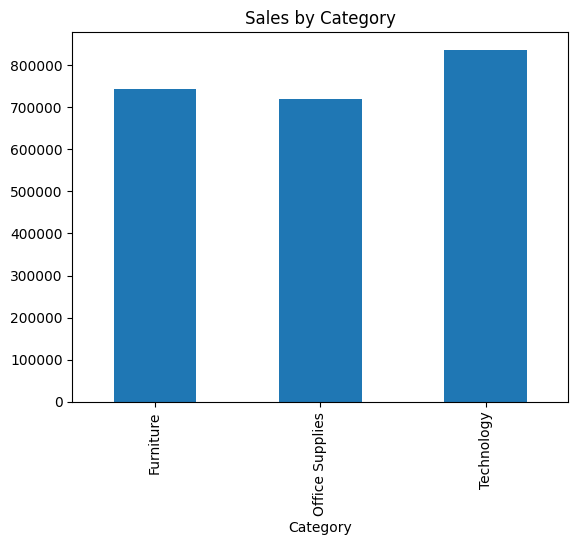

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

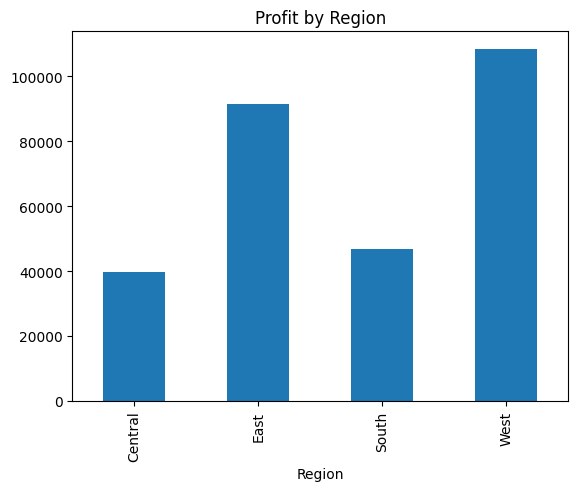

In [ ]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Region")
plt.show()

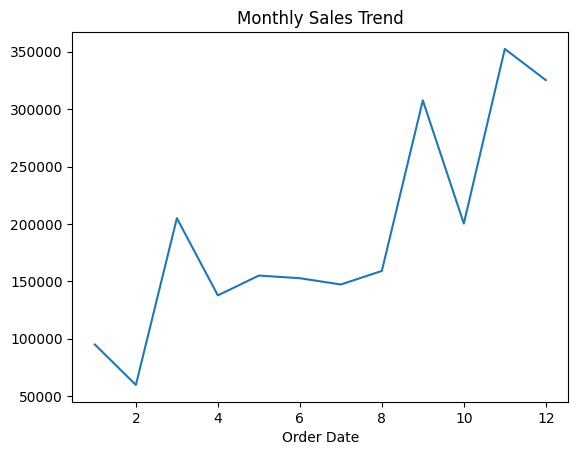

In [ ]:
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

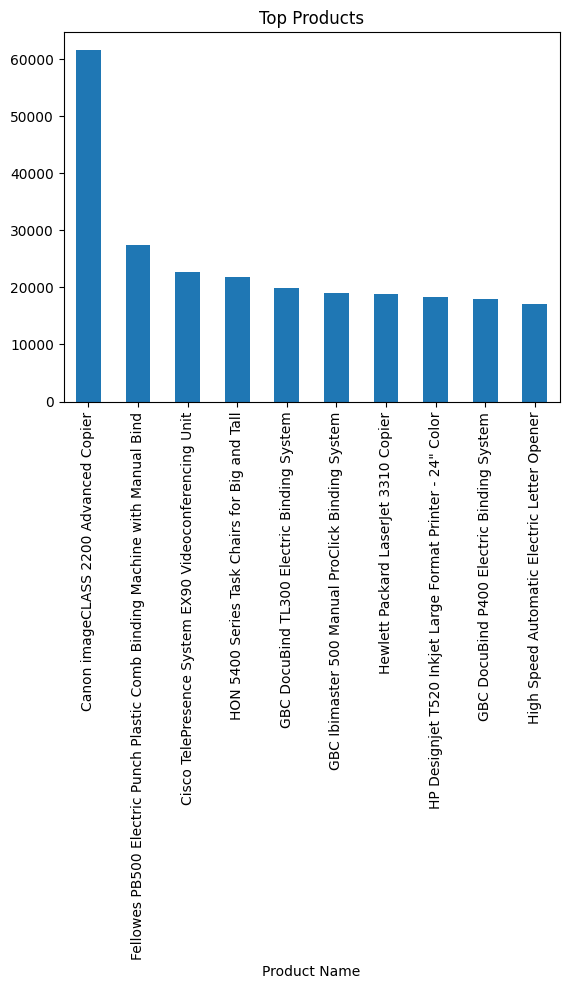

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Products")
plt.show()

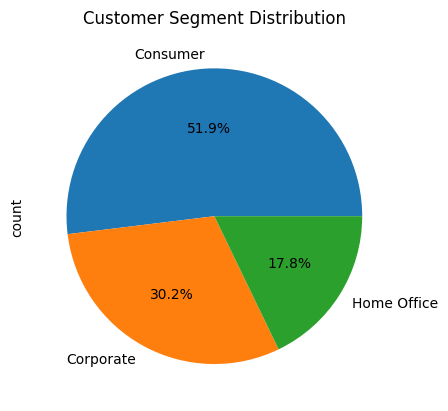

In [ ]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Segment Distribution")
plt.show()

# Business Insights

### Insight 1
The Technology category generated the highest sales revenue, indicating strong customer demand for technology products.

### Insight 2
The West region contributed the highest profit, making it the most profitable region for the business.

### Insight 3
Monthly sales trends showed seasonal fluctuations, suggesting that demand varies throughout the year.

### Insight 4
A small number of products generated a disproportionately large share of revenue, indicating that top-performing products have a significant impact on overall sales.

### Insight 5
The Consumer segment represented the largest share of customers, making it the primary target customer group.

# Conclusion

This project analyzed Superstore sales data using Pandas, SQLite, and Matplotlib. Data was cleaned and transformed, SQL queries were used to identify sales and profit trends, and visualizations were created to support decision-making. The analysis revealed top-performing categories, products, and regions, providing actionable business insights.

# Skills Demonstrated

- Python
- Pandas
- Data Cleaning
- SQL (SQLite)
- Data Visualization
- Business Analysis
- Jupyter/Google Colab
- GitHub